In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k, mu_0, pi
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

# This code defines the functions to simulated XRD and M-H pairs of data

# Load CIF structures 
fe3o4_struct = Structure.from_file("1010369_Fe3O4.cif")
feo_struct   = Structure.from_file("1011169_FeO.cif")
alphaFe2O3_struct   = Structure.from_file("1011240_Hematite.cif") # not used currently


# Simulated normalized XRD for Fe3O4/FeO mixing using scherrer broadening for each phase, intrumental broadening (in quadrature) and Pseudo-Voigt peak shapes
def simulate_xrd_fe3o4_feo(grain_size_fe3o4_nm,
                           grain_size_feo_nm,
                           phase_frac_fe3o4,
                           two_theta_range=(25, 65),
                           num_points=2000,
                           K=0.9,
                           wavelength=1.5406,
                           instr_fwhm_deg=0.02): 
    
    
    calc = XRDCalculator(wavelength="CuKa")
    two_theta = np.linspace(*two_theta_range, num_points)
    intensity = np.zeros_like(two_theta)

    # Define mapping from structure to size and phase fraction
    phases = [
        (fe3o4_struct, phase_frac_fe3o4, grain_size_fe3o4_nm),
        (feo_struct,   1 - phase_frac_fe3o4, grain_size_feo_nm)
    ]

    for struct, frac, gs_nm in phases:
        pat = calc.get_pattern(struct, two_theta_range=two_theta_range)
        D_A = gs_nm * 10.0  # convert nm to anstrom
        for x0, I0 in zip(pat.x, pat.y):
            theta0 = np.radians(x0 / 2)
            # Scherrer size broadening
            beta_size_rad = (K * wavelength) / (D_A * np.cos(theta0))
            beta_size_deg = beta_size_rad * 180 / np.pi
            # Total FWHM
            beta_total = np.sqrt(beta_size_deg**2 + instr_fwhm_deg**2)
            # Pseudo-Voigt
            sigma_G = beta_total / (2 * np.sqrt(2 * np.log(2)))
            gamma_L = beta_total / 2
            eta = 0.3 #Gaussian and Lorentzian mixing parameter
            diff = two_theta - x0
            G = np.exp(-diff**2 / (2 * sigma_G**2)) / (sigma_G * np.sqrt(2 * np.pi))
            L = (1 / np.pi) * (gamma_L / (diff**2 + gamma_L**2))
            
            intensity += frac * I0 * (eta * L + (1 - eta) * G)

    # Normalize to max = 1
    intensity /= intensity.max()
    return two_theta, intensity

# Simulate Langevin model for Fe3O4, surface effect/ spin canting for scaling Ms(D), linear paramagnetic FeO contribution, returns field array (T) and total magnetization in (Am^2/kg)
def simulate_hysteresis_langevin(grain_size_nm,
                                      phase_frac_fe3o4,
                                      spin_canting_layer_nm=0.3, # Could be tuned depending on experimental data
                                      chi_mass=1e-6,
                                      T=300.0,
                                      B_min=-2.8,
                                      B_max=2.8,
                                      n_points=300):

    # Size-dependent Ms via core–shell surface layer
    Ms_bulk = 92.0  # Am^2/kg
    d, t = grain_size_nm, spin_canting_layer_nm
    Ms_size = 0.0 if d <= 2*t else Ms_bulk * ((d - 2*t)/d)**3

    # Paramagnetic FeO 
    slope_para = chi_mass/ mu_0

    # Effective moment per particle
    r      = 0.5 * d * 1e-9         # radius in m
    V      = (4/3) * pi * r**3      # volume in m^3
    rho    = 5220.0                 # kg/m^3
    m_p    = rho * V                # kg
    mu_eff = Ms_size * m_p          # Am^2

    # Field grid
    B = np.linspace(B_min, B_max, n_points)

    # Langevin function
    alpha = mu_eff * B / (k * T)
    L = np.zeros_like(alpha)
    mask = np.abs(alpha) > 1e-8
    L[mask] = 1/np.tanh(alpha[mask]) - 1/alpha[mask]

    # Mixed phased magnetization
    M_spm  = phase_frac_fe3o4 * Ms_size * L
    M_para = (1 - phase_frac_fe3o4) * slope_para * B
    M_tot  = M_spm + M_para

    return B, M_tot

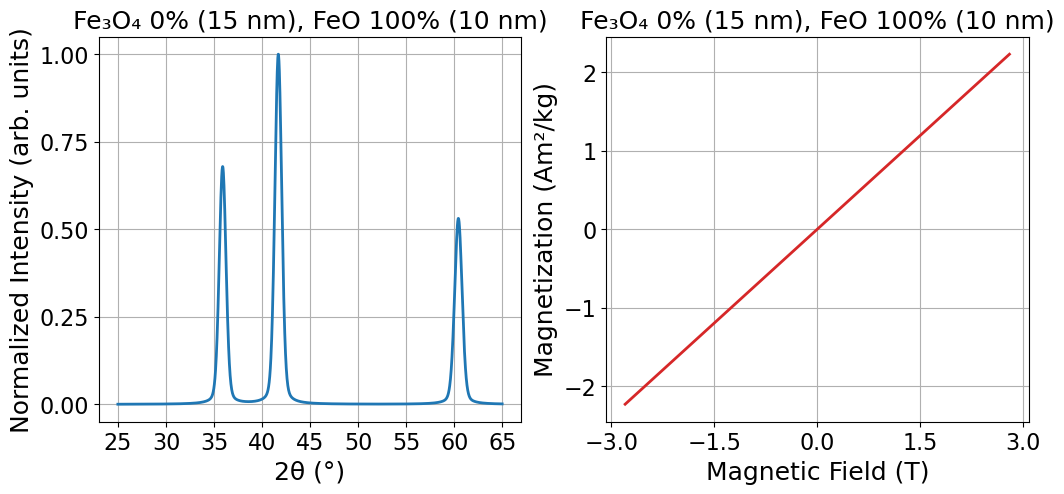

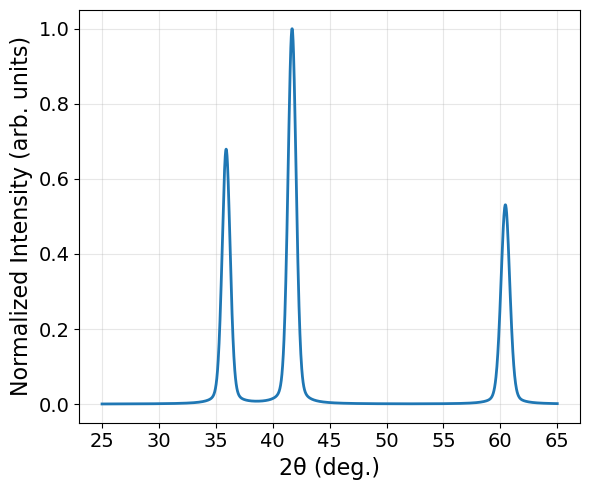

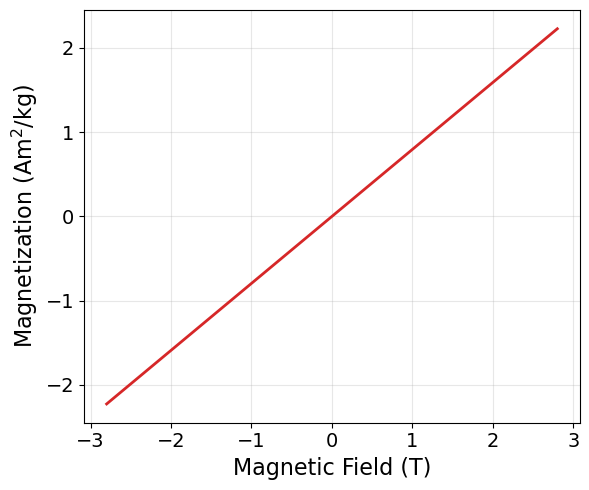

In [4]:
import matplotlib.pyplot as plt

# This code plots XRD and M-H that can be generated from the simulation functions

# Sample parameters 
grain_size_fe3o4 = 15     # Fe3O4 grain size in nm
grain_size_feo   = 10    # FeO grain size in nm 
phase_frac       = 0.0      # fraction of Fe3O4 (0–1)

# Simulate XRD
two_theta, xrd_intensity = simulate_xrd_fe3o4_feo(
    grain_size_fe3o4_nm=grain_size_fe3o4,
    grain_size_feo_nm=grain_size_feo,
    phase_frac_fe3o4=phase_frac
)

# Simulate Langevin-paramagnetic M–H curve
B_field, M_curve = simulate_hysteresis_langevin(
    grain_size_nm=grain_size_fe3o4,
    phase_frac_fe3o4=phase_frac
)

# Plot side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Font size parameters
label_fontsize = 18
tick_fontsize = 16
title_fontsize = 18

# XRD plot
ax1.plot(two_theta, xrd_intensity, lw=2.0, color='tab:blue')
ax1.set_xlabel('2θ (°)', fontsize=label_fontsize)
ax1.set_ylabel('Normalized Intensity (arb. units)', fontsize=label_fontsize)
ax1.set_title(
    f'Fe₃O₄ {phase_frac*100:.0f}% ({grain_size_fe3o4:.0f} nm), '
    f'FeO {(1-phase_frac)*100:.0f}% ({grain_size_feo:.0f} nm)',
    fontsize=title_fontsize
)
ax1.set_xticks([25, 30, 35, 40, 45, 50, 55, 60, 65])
ax1.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax1.tick_params(axis='both', labelsize=tick_fontsize)
ax1.grid(True)

# M–H plot
ax2.plot(B_field, M_curve, lw=2.0, color='tab:red')
ax2.set_xlabel('Magnetic Field (T)', fontsize=label_fontsize)
ax2.set_ylabel('Magnetization (Am²/kg)', fontsize=label_fontsize)
ax2.set_title(
    f'Fe₃O₄ {phase_frac*100:.0f}% ({grain_size_fe3o4:.0f} nm), '
    f'FeO {(1-phase_frac)*100:.0f}% ({grain_size_feo:.0f} nm)',
    fontsize=title_fontsize
)
ax2.tick_params(axis='both', labelsize=tick_fontsize)
ax2.set_xticks([-3, -1.5, 0, 1.5, 3])
ax2.grid(True)

# Seperate plots

# XRD plot
plt.figure(figsize=(6, 5))
plt.plot(two_theta, xrd_intensity, lw=2, color='tab:blue')
plt.xlabel("2θ (deg.)", fontsize=16)
plt.ylabel("Normalized Intensity (arb. units)", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
#plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# M-H plot
plt.figure(figsize=(6, 5))
plt.plot(B_field, M_curve, lw=2, color='tab:red')
plt.xlabel("Magnetic Field (T)", fontsize=16)
plt.ylabel("Magnetization (Am$^2$/kg)", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
#plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
import json

# Generates simulated dataset of size N

# Dataset size
N = 50

# Sample random parameters 
grain_sizes_fe3o4 = np.random.uniform(3.0, 50.0, size=N)  # Fe3O4 grain/crystallite size (nm)
grain_sizes_feo   = np.random.uniform(3.0, 50.0, size=N)  # FeO grain/crystallite size (nm)
phase_fracs       = np.random.uniform(0.0, 1.0, size=N)   # Fe3O4 fraction 

# Grid sizes
theta_grid, _ = simulate_xrd_fe3o4_feo(
    grain_size_fe3o4_nm=grain_sizes_fe3o4[0],
    grain_size_feo_nm=  grain_sizes_feo[0],
    phase_frac_fe3o4=  phase_fracs[0]
)
n_xrd = theta_grid.size

B_grid, _ = simulate_hysteresis_langevin(
    grain_size_nm=      grain_sizes_fe3o4[0],
    phase_frac_fe3o4=   phase_fracs[0]
)
n_hyst = B_grid.size

# Preallocate storage 
xrd_data = np.zeros((N, n_xrd), dtype=np.float32)
mh_data  = np.zeros((N, n_hyst), dtype=np.float32)

# labels: [D_Fe3O4, D_FeO, frac_Fe3O4, max_M]
labels   = np.zeros((N, 4), dtype=np.float32)

# Generate dataset 
for i in range(N):
    d1 = grain_sizes_fe3o4[i]
    d2 = grain_sizes_feo[i]
    f  = phase_fracs[i]

    # XRD simulation
    _, I = simulate_xrd_fe3o4_feo(
        grain_size_fe3o4_nm = d1,
        grain_size_feo_nm = d2,
        phase_frac_fe3o4 = f
    )
    xrd_data[i, :] = I

    # M vs. H simulation
    _, M = simulate_hysteresis_langevin(
        grain_size_nm=    d1,
        phase_frac_fe3o4= f
    )
    mh_data[i, :] = M

    # Store labels
    labels[i, 0] = d1          # Fe3O4 size
    labels[i, 1] = d2          # FeO size
    labels[i, 2] = f           # Fe3O4 fraction
    labels[i, 3] = M.max()     # Max magnetization/ magnetization at 3T

# Save data
np.savez('fe3o4_feo_dataset_N_50.npz',
         two_theta=theta_grid,
         B_field=B_grid,
         xrd=xrd_data,
         M_hysteresis=mh_data,
         labels=labels)

print(f"Saved {N} samples to fe3o4_feo_dataset_N_50.npz")

# Save data as JSON
json_path = f"fe3o4_feo_dataset_N_{N}.json"

samples = []
for i in range(N):
    samples.append({
        "id": int(i),
        "xrd": xrd_data[i].tolist(),
        "labels": {
            "D_Fe3O4_nm": float(labels[i, 0]),
            "D_FeO_nm":   float(labels[i, 1]),
            "frac_Fe3O4": float(labels[i, 2]),
            "max_M":      float(labels[i, 3]),
        }
    })

payload = {
    "two_theta": theta_grid.tolist(),
    "samples": samples
}

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

Saved 50 samples to fe3o4_feo_dataset_N_50.npz


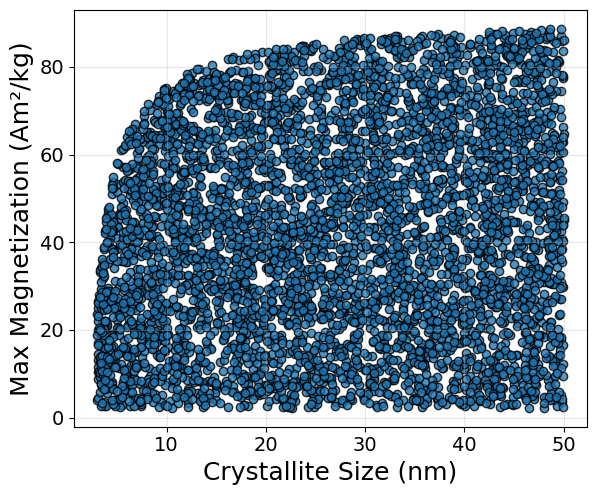

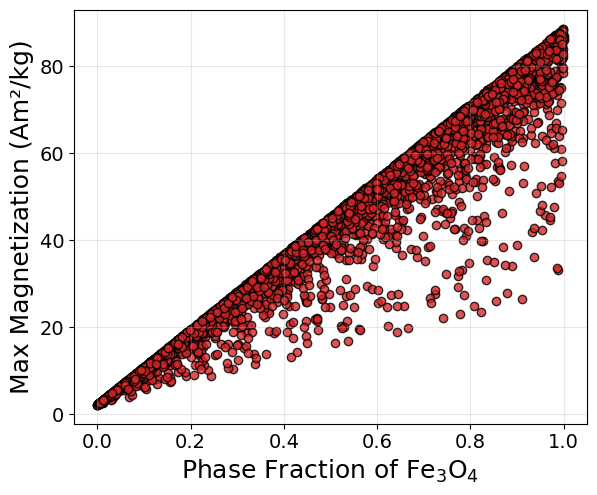

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visulization of datasets

# Load simulate data
data = np.load('fe3o4_feo_dataset_N_5000.npz')
labels = data['labels']
# columns: [D_Fe3O4, D_FeO, frac_Fe3O4, M]
grain_sizes_fe3o4 = labels[:, 0]
fe3o4_fractions   = labels[:, 2]
M_values          = labels[:, 3]

# Plot Magnetixzation at 2.8 T vs. Fe3O4 crystallite size
plt.figure(figsize=(6, 5))
plt.scatter(grain_sizes_fe3o4, M_values, c='tab:blue', edgecolors='k', alpha=0.8)
plt.xlabel('Crystallite Size (nm)', fontsize=18)
plt.ylabel('Max Magnetization (Am²/kg)', fontsize=18)
#plt.title('Title', fontsize =14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# Plot Magnetization vs. Fe3O4 phase fraction
plt.figure(figsize=(6, 5))
plt.scatter(fe3o4_fractions, M_values, c='tab:red', edgecolors='k', alpha=0.8)
plt.xlabel('Phase Fraction of Fe$_3$O$_4$', fontsize=18)
plt.ylabel('Max Magnetization (Am²/kg)', fontsize=18)
#plt.title('Title', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

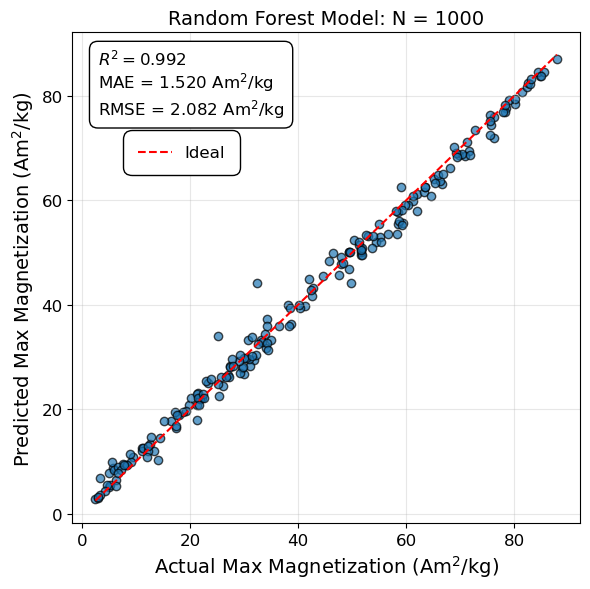

Random Forest model saved to rf_model_fe3o4_feo_dataset_N_1000_v2.pkl


In [61]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Trains a random forest regression model using the simulated dataset

#  Load simulated dataset
data = np.load('fe3o4_feo_dataset_N_1000.npz') 
X = data['xrd']                         # shape (N, n_xrd)
y = data['labels'][:, 3]                # max magnetization 

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,      
    max_features="sqrt",  # v1 0.3, v2 sqrt  
    random_state=1,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Compute metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Plot predicted vs. actual 
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal')
plt.xlabel('Actual Max Magnetization (Am$^2$/kg)', fontsize=14)
plt.ylabel('Predicted Max Magnetization (Am$^2$/kg)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Random Forest Model: N = 1000', fontsize=14)

textstr = '\n'.join((
    f'$R^2 = {r2:.3f}$',
    f'MAE = {mae:.3f} Am$^2$/kg',
    f'RMSE = {rmse:.3f} Am$^2$/kg',
))
plt.text(0.05, 0.97, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=1.0))

legend = plt.legend(loc='upper left', bbox_to_anchor=(0.1, 0.8),
                    fontsize=12, frameon=True)

frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_alpha(1.0)
frame.set_linewidth(1.0)
frame.set_boxstyle("round,pad=0.5") 

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save the trained model as .pkl
model_path = 'rf_model_fe3o4_feo_dataset_N_1000_v2.pkl'
joblib.dump(rf, model_path)
print(f"Random Forest model saved to {model_path}")

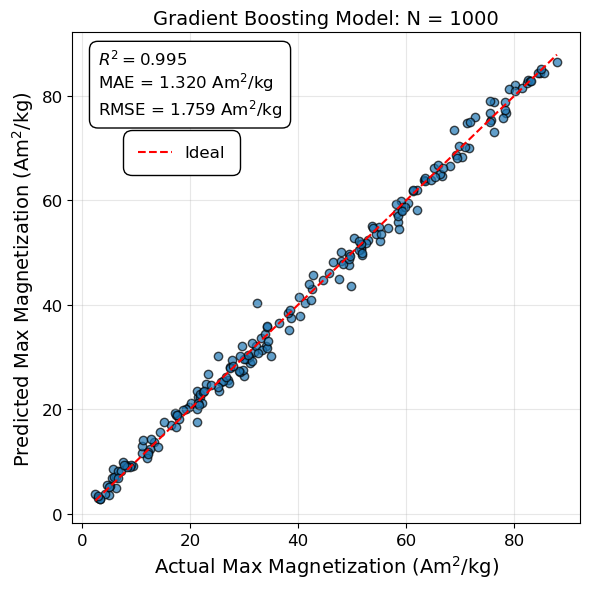

Gradient Boosting model saved to gb_model_fe3o4_feo_dataset_N_1000_v2.pkl


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load simulated dataset
data = np.load('fe3o4_feo_dataset_N_1000.npz')       
X = data['xrd']                                   # shape (N, n_xrd)
y = data['labels'][:, 3]                          # Max Magnetization

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train Gradient Boosting

# v1 conditions
#gb = GradientBoostingRegressor(
#        n_estimators=500,
#        learning_rate=0.05,
#        max_depth=3,
#        random_state=1)

# v2 conditions
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,        
    min_samples_leaf=5,   
    random_state=1
)


gb.fit(X_train, y_train)

# Predict on test set
y_pred = gb.predict(X_test)

# Compute metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Plot predicted vs. actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal')  # 1:1 dashed line

plt.xlabel('Actual Max Magnetization (Am$^2$/kg)', fontsize=14)
plt.ylabel('Predicted Max Magnetization (Am$^2$/kg)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Gradient Boosting Model: N = 1000', fontsize=14)

textstr = '\n'.join((
    f'$R^2 = {r2:.3f}$',
    f'MAE = {mae:.3f} Am$^2$/kg',
    f'RMSE = {rmse:.3f} Am$^2$/kg',
))
plt.text(0.05, 0.97, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=1.0))

legend = plt.legend(loc='upper left', bbox_to_anchor=(0.1, 0.8),
                    fontsize=12, frameon=True)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_alpha(1.0)
frame.set_linewidth(1.0)
frame.set_boxstyle("round,pad=0.5")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save the trained model
model_path = 'gb_model_fe3o4_feo_dataset_N_1000_v2.pkl'
joblib.dump(gb, model_path)
print(f"Gradient Boosting model saved to {model_path}")

Train R²: 0.9971 | Test R²: 0.9925
Computing permutation importance...


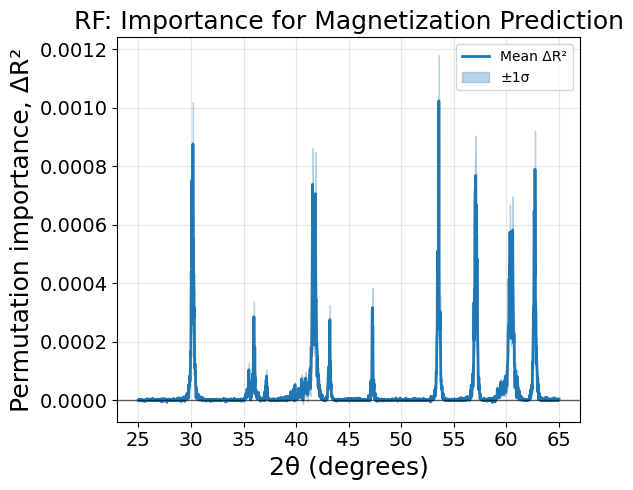

Random Forest model saved to rf_model_fe3o4_feo_dataset_N_1000_v2_features.pkl


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Load simulated Fe3O4–FeO dataset
data = np.load('fe3o4_feo_dataset_N_1000.npz')
X = data['xrd']                             # shape (N_samples, N_xrd_points)
y = data['labels'][:, 3]                    # Magnetization at 3 Tesla (Am^2/kg)
two_theta = data['two_theta']               # 2θ values from simulation grid

# Sanity check: features 
assert X.shape[1] == two_theta.shape[0], (
    f"Feature count ({X.shape[1]}) must match two_theta length ({two_theta.shape[0]})."
)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train Random Forest model
rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,      
    max_features="sqrt",  # v1 0.3, v2 sqrt  
    random_state=1,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

# Baseline scores for context
train_r2 = rf.score(X_train, y_train)
test_r2  = rf.score(X_test, y_test)
print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

# Compute permutation importance
print("Computing permutation importance...")
result = permutation_importance(
    rf, X_test, y_test, n_repeats=30, random_state=1, n_jobs=-1
)

imp_mean = result.importances_mean
imp_std  = result.importances_std

# Plot Feature Importance (signed; 0 reference)
plt.figure(figsize=(6, 5))
plt.plot(two_theta, imp_mean, lw=2, color='tab:blue', label='Mean ΔR²')
plt.fill_between(
    two_theta,
    imp_mean - imp_std,
    imp_mean + imp_std,
    color='tab:blue', alpha=0.3, label='±1σ'
)
plt.axhline(0.0, color='k', lw=1, alpha=0.6)

plt.xlabel(r"2θ (degrees)", fontsize=18)
plt.ylabel("Permutation importance, ΔR²", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("RF: Importance for Magnetization Prediction", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Save RF model
out_dir = Path(".")
model_path = out_dir / 'rf_model_fe3o4_feo_dataset_N_1000_v2_features.pkl'
joblib.dump(rf, model_path)
print(f"Random Forest model saved to {model_path}")

# Save importances
np.savez(
    out_dir / "rf_perm_importance_N_1000_v2.npz",
    two_theta=two_theta,
    importances_mean=imp_mean,
    importances_std=imp_std,
    train_r2=train_r2,
    test_r2=test_r2,
)


Train R²: 0.9997 | Test R²: 0.9946
Computing permutation importance...


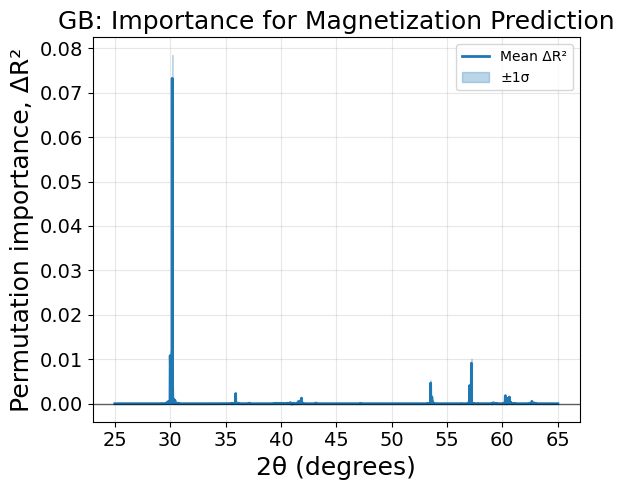

Random Forest model saved to gb_model_fe3o4_feo_dataset_N_1000_v2_features.pkl


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

# -----------------------
# Load simulated dataset
# -----------------------
data = np.load("fe3o4_feo_dataset_N_1000.npz")
X = data["xrd"]                 # (N_samples, N_features)
y = data["labels"][:, 3]        # Magnetization at 3 T (Am^2/kg)
two_theta = data["two_theta"]   # (N_features,)

# sanity check: features <-> 2θ alignment
assert X.shape[1] == two_theta.shape[0], (
    f"Feature count ({X.shape[1]}) must match two_theta length ({two_theta.shape[0]})."
)

# -----------------------
# Train/Test split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# -----------------------
# Train Gradient Boosting
# -----------------------
# v1 conditions
#gb = GradientBoostingRegressor(
#        n_estimators=500,
#        learning_rate=0.05,
#        max_depth=3,
#        random_state=1)

# v2 conditions
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,        
    min_samples_leaf=5,   
    random_state=1
)



gb.fit(X_train, y_train)

train_r2 = gb.score(X_train, y_train)
test_r2  = gb.score(X_test, y_test)
print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

# -----------------------
# Permutation importance
# -----------------------
print("Computing permutation importance...")
# n_repeats↑ yields smoother estimates; scoring defaults to R² for regressors
result = permutation_importance(
    gb, X_test, y_test, n_repeats=30, random_state=1, n_jobs=-1
)

imp_mean = result.importances_mean
imp_std  = result.importances_std

# Plot Feature Importance (signed; 0 reference)
plt.figure(figsize=(6, 5))
plt.plot(two_theta, imp_mean, lw=2, color='tab:blue', label='Mean ΔR²')
plt.fill_between(
    two_theta,
    imp_mean - imp_std,
    imp_mean + imp_std,
    color='tab:blue', alpha=0.3, label='±1σ'
)
plt.axhline(0.0, color='k', lw=1, alpha=0.6)

plt.xlabel(r"2θ (degrees)", fontsize=18)
plt.ylabel("Permutation importance, ΔR²", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("GB: Importance for Magnetization Prediction", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Save RF model
out_dir = Path(".")
model_path = out_dir / 'gb_model_fe3o4_feo_dataset_N_1000_v2_features.pkl'
joblib.dump(gb, model_path)
print(f"Random Forest model saved to {model_path}")

# Save importances & scores for later analysis
np.savez(
    out_dir / "gb_perm_importance_N_1000_v2.npz",
    two_theta=two_theta,
    importances_mean=imp_mean,
    importances_std=imp_std,
    train_r2=train_r2,
    test_r2=test_r2,
)
